# Climate Change Modeling using Machine Learning and NLP

-------
### Tools Used:
- Jupyter Notebook
- Python Libraries: Pandas, NumPy, Matplotlib, Seaborn, NLTK, TextBlob, Scikit-learn, Plotly, WordCloud

--------
### Technologies:
- Machine Learning
- Natural Language Processing (NLP)
- Time Series Forecasting
---------

### Datasets:
- NASA Facebook Comments Dataset (Provided)
- Historical Climate Data from sources like NASA, NOAA:
    - CO2 levels
    - Temperature anomalies
    - Sea level rise
    - Precipitation
---------

# PART 2: Climate Indicator Prediction using Machine Learning

In [1]:
# Part 2: Climate Change Modeling using Machine Learning and NLP

# 2.1 Load libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 2.2 Load data
df = pd.read_csv('climate_nasa.csv')

# 2.3 Drop rows with missing 'text'
df.dropna(subset=['text'], inplace=True)

In [2]:
# 2.4 ----- NLP MODEL -----
# Sentiment Analysis on comment text
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

df['sentiment'] = df['text'].apply(get_sentiment)

# Label sentiment: Positive (>0), Neutral (=0), Negative (<0)
df['sentiment_label'] = df['sentiment'].apply(lambda x: 1 if x > 0 else (0 if x == 0 else -1))

# NLP Classification Model: Predict sentiment label from text length and commentsCount
df['text_length'] = df['text'].apply(lambda x: len(x))
df['commentsCount'] = df['commentsCount'].fillna(0)

X_nlp = df[['text_length', 'commentsCount']]
y_nlp = df['sentiment_label']

X_nlp_train, X_nlp_test, y_nlp_train, y_nlp_test = train_test_split(X_nlp, y_nlp, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_nlp_train, y_nlp_train)
y_nlp_pred = clf.predict(X_nlp_test)

print("--- NLP Model Results ---")
print("Sentiment Classification Accuracy:", accuracy_score(y_nlp_test, y_nlp_pred))

--- NLP Model Results ---
Sentiment Classification Accuracy: 0.5643564356435643


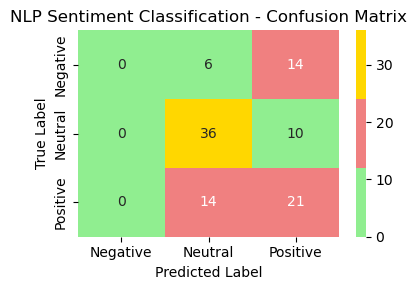

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap # <-- Import the necessary function

# Define the colors you want to use
colors = ['lightgreen', 'lightcoral', 'gold']
# Create a custom colormap from the list of colors
custom_cmap = ListedColormap(colors)

# Confusion Matrix
cm = confusion_matrix(y_nlp_test, y_nlp_pred, labels=[-1, 0, 1])

# Plot the Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=custom_cmap, # <-- The change is applied here
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.title("NLP Sentiment Classification - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Optional: Print classification report
# print("Classification Report:")
# print(classification_report(y_nlp_test, y_nlp_pred, target_names=['Negative', 'Neutral', 'Positive']))

In [12]:
# 2.5 ----- MACHINE LEARNING MODEL -----
# Predict likesCount using sentiment score and commentsCount
df['likesCount'] = df['likesCount'].fillna(0)

X_ml = df[['sentiment', 'commentsCount']]
y_ml = df['likesCount']

X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_ml_train, y_ml_train)
y_ml_pred = model.predict(X_ml_test)

print("--- ML Model Results ---")
print("MSE:", mean_squared_error(y_ml_test, y_ml_pred))
print("R² Score:", r2_score(y_ml_test, y_ml_pred))

--- ML Model Results ---
MSE: 177.85915395826117
R² Score: 0.2595033362903185


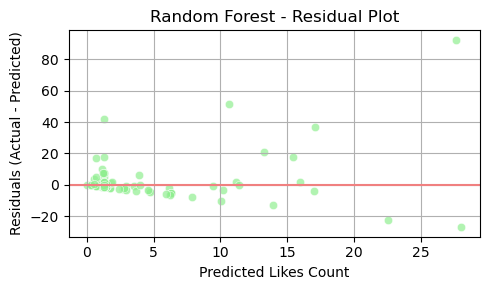

In [30]:
import numpy as np
residuals_rf = y_ml_test - y_ml_pred

plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_ml_pred, y=residuals_rf, color='lightgreen', alpha=0.7)
plt.axhline(y=0, color='lightcoral', linestyle='-')
plt.title("Random Forest - Residual Plot")
plt.xlabel("Predicted Likes Count")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.grid(True)
plt.show()

In [15]:
# 2.7 ----- MACHINE LEARNING MODEL -----
# Gradient Boosting Model for likesCount Prediction
 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Ensure these columns are filled and available
df['likesCount'] = df['likesCount'].fillna(0)
df['commentsCount'] = df['commentsCount'].fillna(0)
X_gb = df[['sentiment', 'commentsCount']]
y_gb = df['likesCount']

X_gb_train, X_gb_test, y_gb_train, y_gb_test = train_test_split(X_gb, y_gb, test_size=0.2, random_state=42)

# Initialize and train the model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_gb_train, y_gb_train)

# Make predictions
y_gb_pred = gb_model.predict(X_gb_test)
gb_mse = mean_squared_error(y_gb_test, y_gb_pred)
gb_r2 = r2_score(y_gb_test, y_gb_pred)

print("--- Gradient Boosting Results ---")
print("MSE:", gb_mse)
print("R² Score:", gb_r2)

--- Gradient Boosting Results ---
MSE: 167.69643429500323
R² Score: 0.3018146811796871


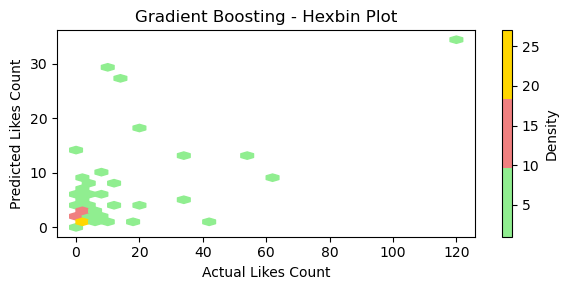

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define the colors you want to use
colors = ['lightgreen', 'lightcoral', 'gold']
# Create a custom colormap from the list of colors
custom_cmap = ListedColormap(colors)

# Assuming y_gb_test and y_gb_pred are defined

plt.figure(figsize=(6, 3))
# Use the custom_cmap
plt.hexbin(
    y_gb_test,
    y_gb_pred,
    gridsize=30,
    cmap=custom_cmap,
    mincnt=1
)
# REMOVED: plt.plot([y_gb_test.min(), y_gb_test.max()], [y_gb_test.min(), y_gb_test.max()] )
plt.xlabel("Actual Likes Count")
plt.ylabel("Predicted Likes Count")
plt.title("Gradient Boosting - Hexbin Plot")
plt.colorbar(label='Density')
plt.tight_layout()
plt.show()

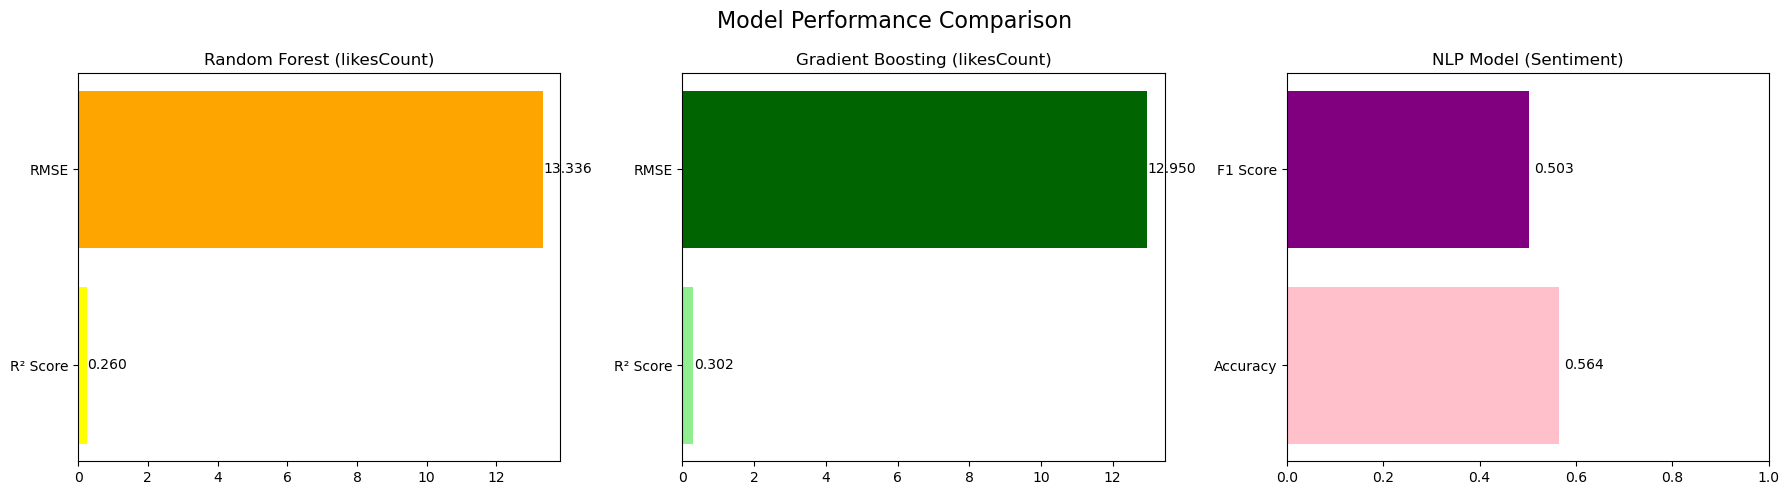

In [18]:
# # 1.8 ----- MODEL EVALUATION -----
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# -- 1. Random Forest Model Performance (likesCount) --
r2_rf = r2_score(y_ml_test, y_ml_pred)
rmse_rf = np.sqrt(mean_squared_error(y_ml_test, y_ml_pred))

# -- 2. Gradient Boosting Model Performance (likesCount) --
r2_gb = r2_score(y_gb_test, y_gb_pred)
rmse_gb = np.sqrt(mean_squared_error(y_gb_test, y_gb_pred))

# -- 3. NLP Model Performance (sentiment classification) --
acc = accuracy_score(y_nlp_test, y_nlp_pred)
f1 = f1_score(y_nlp_test, y_nlp_pred, average='weighted')

# --- Visualization: Model Performance Comparison ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Performance Comparison", fontsize=16)

# Plot 1: Random Forest
axs[0].barh(['R² Score', 'RMSE'], [r2_rf, rmse_rf], color=['yellow', 'orange'])
axs[0].set_title("Random Forest (likesCount)")
axs[0].set_xlim([0, max(r2_rf, rmse_rf) + 0.5])
for i, v in enumerate([r2_rf, rmse_rf]):
    axs[0].text(v + 0.01, i, f"{v:.3f}", va='center')

# Plot 2: Gradient Boosting
axs[1].barh(['R² Score', 'RMSE'], [r2_gb, rmse_gb], color=['lightgreen', 'darkgreen'])
axs[1].set_title("Gradient Boosting (likesCount)")
axs[1].set_xlim([0, max(r2_gb, rmse_gb) + 0.5])
for i, v in enumerate([r2_gb, rmse_gb]):
    axs[1].text(v + 0.01, i, f"{v:.3f}", va='center')

# Plot 3: NLP Model
axs[2].barh(['Accuracy', 'F1 Score'], [acc, f1], color=['pink', 'purple'])
axs[2].set_title("NLP Model (Sentiment)")
axs[2].set_xlim([0, 1])
for i, v in enumerate([acc, f1]):
    axs[2].text(v + 0.01, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()